<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB3_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import auc, roc_curve, confusion_matrix
import matplotlib.pyplot as plt

# Helper questions

1. **Would a different threshold yield better results?**  
How does shifting the threshold affect the **trade-off between sensitivity and specificity**?

The expression that a binary logistic regression models directly is:
$$\mathbb{P}(y = 1 | X = x) = \frac{1}{1 + e^{-\beta_0 - \beta x}}$$

The final prediction of the model depends on the threshold we set. Choosing a lower threshold will result in classifying more observations as $true$ (for example we might want to predict $true$ if there is even $10\%$ chance that it is in fact $true$). Conversely, a higher threshold will require a high certainty to predict $y = 1$.

Sensitivity is a measure of how many of the observations that are actually true, we've actually found:
$$sensitivity = TPR = \frac{TP}{TP + FN}$$
Relying on sensitivity reduces risk of obtaining false negatives.

Specificity is a measure of how well the model is able to recognize false values.
$$specificity = 1 - FPR = \frac{TN}{TN + FP}$$
Relying on specificity reduses risk of obtaining false positives.

2. **How do you define "better" results?**  
Is **higher specificity** more valuable than **higher sensitivity** in certain contexts? Or maybe the other way around?
Does the **best threshold** depend on the task? (discuss cases like *disease detection* vs. *spam filtering*)

Choosing a proper threshold highly depends on a context. In certain situations, the cost of incorrectly missing a positive might be higher than incorrectly recogniziong one (for example disease detection, this case will be explained in more in the modelling part), whereas sometimes it is better to label the observarions we are not sure about as false (like in spam filtering - missing an important email is less preferable than getting some spam once in a while). The definition of good and bad results and whether we value specifity or sensitivty more should be set for every task individually.

3. **How does a ROC curve help in this process?**  
Learn how to use a **ROC curve** to visualize the trade-off between **True Positive Rate (Sensitivity)** and **False Positive Rate (1 - Specificity)**.

The ROC curve visualizes pairs of $(FPR, TPR)$ at each possible threshold. Since it is constant on many intervals, it allows us to recognize thresholds that are not effective - for example if $TPR = 0.7$ for $0.3 <= FPR < 0.5$, the threshold associated with $FPR = 0.3$ is better than any other threshold associated with $0.3 < FPR < 0.5$ regardless of the context. After narrowing our selection to the sensible thresholds we may use ROC to choose the best one with respect to the sensitivity-specificity trade-off preferences.



4. **How do you select the optimal threshold using the ROC curve?**  
Discuss strategies to select a threshold depending on the specific task at hand and the acceptable **trade-off between sensitivity and specificity**.

(Expanding on the answer from **3**)\
Ideally we would like to be able to define the cost of getting a false positive and a false negative and then select a threshold that minimises:
$$cost = cost_{FN} \cdot (1 - TPR) + cost_{FP} \cdot FPR$$

In many situations it is hard to put a number on a missclasification - then one has to make the choice intuitively with regard to the task specification.


5. **What is the AUC metric and how is it useful?**  
Define **AUC (Area Under the Curve)** and discuss its role in evaluating the overall performance of a classifier.

AUC is the area under the ROC curve. It represents the overall ability of the model to distinguish between the label classes (accounting for all the possible threshold levels). It is therefore not useful when selecting a threshold but when comparing different classificators (for example logistic regression with neural network for the same task). The closer the AUC is to $1$, the better the classificator.


# Data

Loading and standardizing the Wisconsin breast cancer dataset and dividing it into train, test and validation sets (50/25/25 proportions, stratified). \
In order to better ilustrate the logic behind threshold selection, only the first two features are used (the model trained all the data correctly classifies almost every observation).


In [2]:
X,y = load_breast_cancer(return_X_y= True)
X = X[:, :2]
X_train, X_rest, y_train, y_rest = train_test_split(X,
                                                    y,
                                                    test_size= 0.5,
                                                    stratify= y,
                                                    random_state = 42)

X_validation, X_test, y_validation, y_test = train_test_split(X_rest,
                                                              y_rest,
                                                              test_size= 0.5,
                                                              stratify= y_rest,
                                                              random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)


# Fitting the model and choosing the optimal threshold

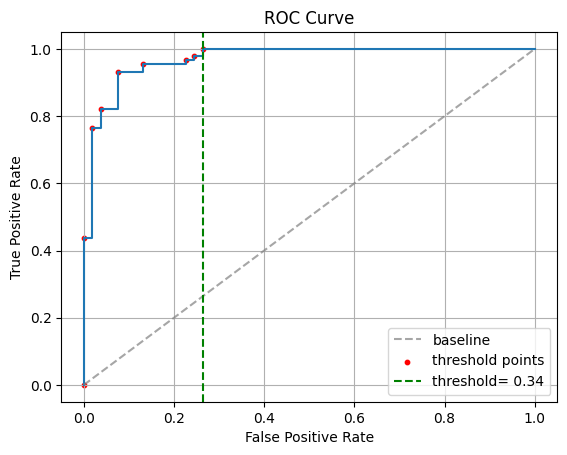

In [3]:
logit = LogisticRegression(random_state= 42)
logit.fit(X_train, y_train)

fpr, tpr, threshold = roc_curve(y_validation, logit.predict_proba(X_validation)[:,1])


plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0,1], [0,1], linestyle= "dashed", color= "gray", alpha= 0.7, label= "baseline")
plt.title("ROC Curve")
plt.scatter(fpr[::2], tpr[::2], s= 10, color= "red", alpha= 1, label= "threshold points")
plt.axvline(x= fpr[-2], color= "green", linestyle= "dashed", label= f"threshold= {threshold[-2]:.2f}")
plt.legend()
plt.grid()
plt.show()

In [4]:
for tp, fp, t in zip(tpr, fpr, threshold):
    print(f"threshold: {t:.2f}, FPR: {fp:.2f}, TPR: {tp:.2f}")

print(f"\nAUC = {auc(fpr, tpr):.2f}")

threshold: inf, FPR: 0.00, TPR: 0.00
threshold: 1.00, FPR: 0.00, TPR: 0.01
threshold: 0.96, FPR: 0.00, TPR: 0.44
threshold: 0.96, FPR: 0.02, TPR: 0.44
threshold: 0.80, FPR: 0.02, TPR: 0.76
threshold: 0.79, FPR: 0.04, TPR: 0.76
threshold: 0.78, FPR: 0.04, TPR: 0.82
threshold: 0.77, FPR: 0.08, TPR: 0.82
threshold: 0.65, FPR: 0.08, TPR: 0.93
threshold: 0.57, FPR: 0.13, TPR: 0.93
threshold: 0.57, FPR: 0.13, TPR: 0.96
threshold: 0.51, FPR: 0.23, TPR: 0.96
threshold: 0.51, FPR: 0.23, TPR: 0.97
threshold: 0.42, FPR: 0.25, TPR: 0.97
threshold: 0.38, FPR: 0.25, TPR: 0.98
threshold: 0.37, FPR: 0.26, TPR: 0.98
threshold: 0.34, FPR: 0.26, TPR: 1.00
threshold: 0.00, FPR: 1.00, TPR: 1.00

AUC = 0.97


The ROC Curve shows a trade-off between the True Positive Rate and the False Positive Rate. The choice of threshold should be based on the preference regarding those two error types.

In this case (diagnosing cancer), obtaining a False Positive prediction is less harmful than obtaining a False Negative, since the latter poses a threat to life. We should therefore put more emphasis on maximizing the sensitivity, than on specificity.

The ROC analysis on the test set shows, that a threshold set to $0.34$ results in $TPR = 1$ and $FPR = 0.26$. That means that for a price of producing a false positive for $26\%$ of healthy patients, we get a model with incredibily low risk of missing a true positive. In this context it is an acceptable trade-off.

The AUC score is equal to $0.97$ which indicates a very good classifier.

# Performance on the test set

In [5]:
y_probs = logit.predict_proba(X_test)
y_predictions = y_probs[:,1] > 0.34

cm = pd.DataFrame(confusion_matrix(y_test, y_predictions),
                  index= ["Actually false", "Actually true"],
                  columns= ["Predicted false", "Predicted true"])

TN, FP, FN, TP = cm.iloc[0,0], cm.iloc[0,1], cm.iloc[1,0], cm.iloc[1,1]
cm

,Predicted false,Predicted true
Actually false,38,15
Actually true,2,88


In [6]:
accuracy = (TP + TN)/(TP + TN + FP + FN)

recall = TP/(TP + FN)
precision = TP/(TP + FP)

f1 = 2/(1/recall + 1/precision) # harmonic mean of recall and precision

sensitivity = recall
specificity = TN/(TN + FP)


print("##### TEST METRICS #######")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")



##### TEST METRICS #######
Accuracy: 0.88
Precision: 0.85
Recall: 0.98
F1-Score: 0.91
Sensitivity: 0.98
Specificity: 0.72


As we can see, the model mantained high sensitivity, which was the main goal given the context. Additionally, the more general metrics (like F1 and accuracy) weren't totally compromised, they mantained a fairly high level.